In [1]:
import torch
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

superindex = ['FutRet', 'DSpot', 'DOilVol', 'xomRet', 'bpRet', 'rdsaRet', 'DInv', 'DProd']
subindex = ['text', 'nontext', 'both', 'ensemble']
multi_index = pd.MultiIndex.from_product([superindex, subindex])

# To use the alternative R² metric, set `MSE_R2=False` when calling these functions (default is True).
# This will still read the same CSV files (e.g., "0-1_FutRet.csv"), but will load different .pt files:
# use "in_sample_updated_0-1_FutRet.pt" when `MSE_R2=True`, or just "in_sample_0-1_FutRet.pt" when `MSE_R2=False`.
def get_R2(true_arr, pred_arr, trend_arr, MSE_R2=True):
    df_arr = pd.DataFrame([true_arr, pred_arr, trend_arr], index=['true','pred','mean']).T
    df_arr = df_arr.dropna().astype(float)
    if MSE_R2:
        num = ((df_arr['true'] - df_arr['pred']) ** 2).mean()
        den = ((df_arr['true'] - df_arr['mean']) ** 2).mean()
    else:
        num = (df_arr['true'] - df_arr['pred']).var()
        den = (df_arr['true'] - df_arr['mean']).var()
    return 1-num/den

def get_flag_R2(MSE_R2):
    if MSE_R2:
        return 'updated_'
    else:
        return ''

# main plot

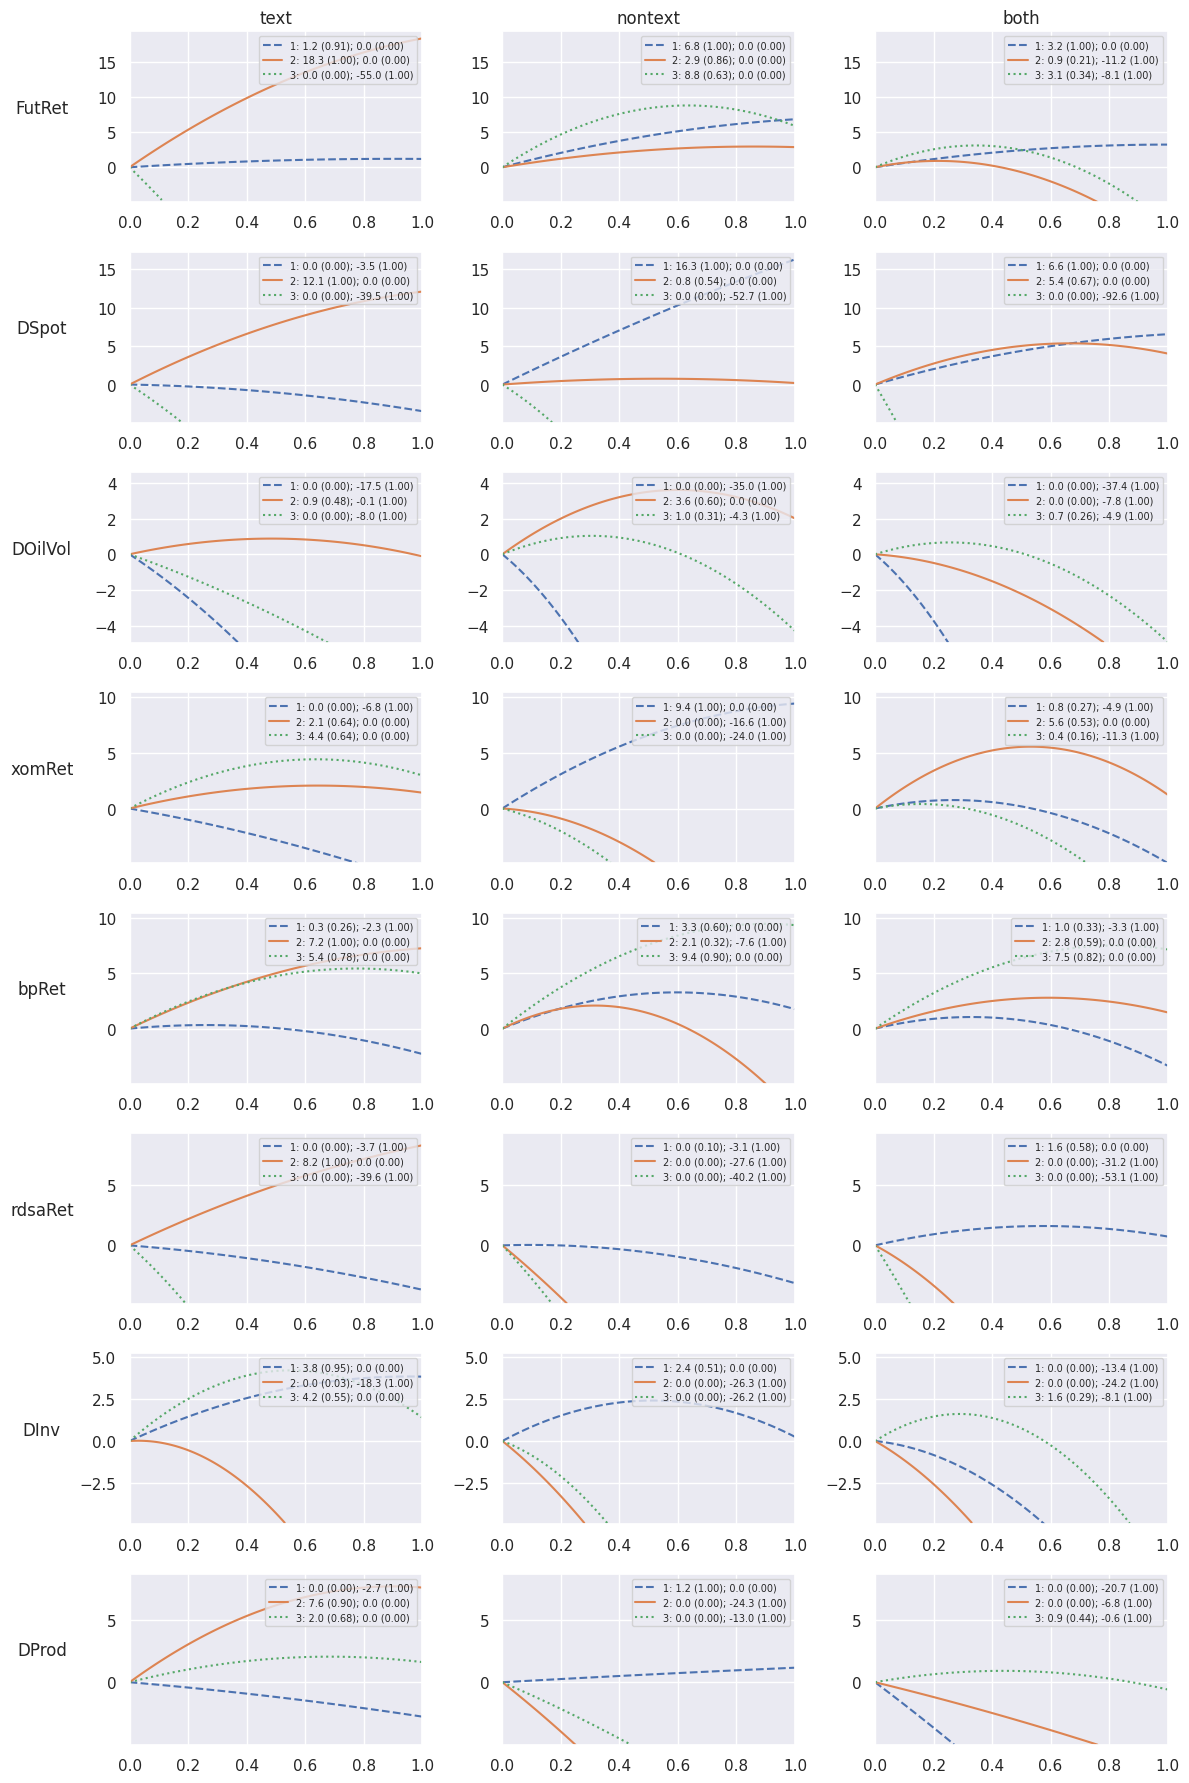

In [2]:
def get_R2_from_df(df_arr, wt, adjusted_var):
    pred_w = wt * df_arr['pred'] + (1 - wt) * df_arr['mean']
    num = ((df_arr['true'] - pred_w)**2).mean()
    return 1-num/adjusted_var

def truncate_negative(arr, threshold=-0.05):
    arr = np.fmax(oos_r2_mid_tercile, threshold)
    arr[np.where(arr==threshold)] = np.nan
    return arr

years_look_back = 4.0
cutoff_year = 2010
wt_max = 1
wt_list = np.linspace(0, wt_max, 101)
nrows = 3

fig, ax = plt.subplots(figsize=(4*nrows, 18), nrows=len(superindex), ncols=nrows)
#for num_nontext_var, num_text_var in zip([0,1,1,0,2,2], [1,0,1,2,0,2]):
for j, d_var in enumerate(superindex):
    row_min = float('inf')
    row_max = float('-inf')
    
    
    for i, (num_nontext_var, num_text_var) in enumerate(zip([0,1,1], [1,0,1])):

        try:
            df = pd.read_csv(f"res_Forward_Lasso/{num_nontext_var}-{num_text_var}_{d_var}.csv", index_col=0)
            df.index = pd.to_datetime(df.index)
#             if j==0 and i==0:
#                 display(df.head())
#                 display(df.tail())
            cutoff_date_start_of_test = pd.Timestamp(f'{cutoff_year}-01-01')
            cutoff_date_end_of_train = cutoff_date_start_of_test - pd.DateOffset(weeks=8)
            df = df[df.index <= cutoff_date_end_of_train]
#             if j==0 and i==0:
#                 display(df.tail())

            legend = []
            temp = []
            for tercile_index, linestyle in zip([1,2,3], ['--','-',':']):
                tercile = df[df[f'lookback_tercile_lag_{years_look_back}yr'] == tercile_index]
                tercile = tercile[['pred','true','mean']].dropna()
                adjusted_var = ((tercile['true'] - tercile['mean'])**2).mean()

                oos_r2_mid_tercile = []
                for wt in wt_list:
                    oos_r2 = get_R2_from_df(tercile, wt, adjusted_var)
                    oos_r2_mid_tercile.append(oos_r2)
                oos_r2_mid_tercile = np.array(oos_r2_mid_tercile)
                oos_r2_mid_tercile_truncated = truncate_negative(oos_r2_mid_tercile)
                
                row_min = min(row_min, np.nanmin(oos_r2_mid_tercile_truncated)*100)
                row_max = max(row_max, np.nanmax(oos_r2_mid_tercile_truncated)*100)
                
                ax[j,i].plot(wt_list, oos_r2_mid_tercile_truncated*100, linestyle)
                oos_max = np.nanmax(oos_r2_mid_tercile)
                temp.append(oos_max*100)
                legend.append(f"{tercile_index}: {oos_max*100:.1f} ({wt_list[np.argmax(oos_r2_mid_tercile)]:.2f}); \
{np.nanmin(oos_r2_mid_tercile)*100:.1f} ({wt_list[np.argmin(oos_r2_mid_tercile)]:.2f})")
            ax[j,i].legend(legend, loc='upper right', fontsize=7)
            ax[j,i].set_xlim((0,1))
            if j == 0:
                ax[j,i].set_title(subindex[i])

        except FileNotFoundError:
            pass
    
    # Set y-axis limits for the entire row
    for i in range(3):
        ax[j,i].set_ylim(row_min, row_max+1)
        ax[j,i].yaxis.set_label_coords(-0.3, (row_min+row_max)/2)  # Adjust this value to align labels
        if i == 0:
            ax[j,i].set_ylabel(d_var, rotation=0, labelpad=20)

fig.tight_layout()
fig.savefig('main_plot.pdf');

# oos-summary-table.tex

In [2]:
def get_best_results(in_sample_best, out_of_sample_best, d_var):

    """
    The following code finds for a given cutoff year \theta and for each lookback window length \ell,
    a 3-tuple consisting of the highest value of R2, its optimal tercile index (1,2,3), 
    and the argmax of weight (0,1,2,...,100).
    For example, an entry of in_sample_results looks like the following:
        2011: {1.0: (0.0, 1, 0),
      1.5: (0.0007311664833195008, 3, 14),
      2.0: (0.0004949109983342082, 3, 11),
      2.5: (0.0003001128575037537, 3, 9),
      3.0: (0.0007800274949746333, 3, 14),
      3.5: (0.008546102998101435, 3, 41),
      4.0: (0.007889789217390919, 3, 40),
      4.5: (0.007024976698513208, 3, 43),
      5.0: (0.005734510462894971, 3, 39)},
    """
    in_sample_results = {}
    out_of_sample_results = {}

    for cutoff_year, look_backs in in_sample_best.items():
        in_sample_results[cutoff_year] = {}
        for look_back, terciles in look_backs.items():
            max_value = -np.inf
            max_tercile = None
            max_index = None
            for tercile, data in terciles.items():
                current_max = np.max(data)
                current_max_index = np.argmax(data)
                if current_max > max_value:
                    max_value = current_max
                    max_tercile = tercile
                    max_index = current_max_index
            in_sample_results[cutoff_year][look_back] = (max_value, max_tercile, max_index)

    for cutoff_year, look_backs in out_of_sample_best.items():
        out_of_sample_results[cutoff_year] = {}
        
        for look_back, terciles in look_backs.items():
            max_tercile = in_sample_results[cutoff_year][look_back][1]
            max_index = in_sample_results[cutoff_year][look_back][2]
            value_at_max_index = terciles[max_tercile][max_index]
            out_of_sample_results[cutoff_year][look_back] = (value_at_max_index, max_tercile, max_index)
            
    return in_sample_results, out_of_sample_results

In [3]:
"""
The ensemble model averages forecasts for a given eight-week ahead return across any of the three 
(text, nontext, both) models – evaluated at their optimal tercile and blending weight at each lookback l  
– that are in the correct tercile.
"""

MSE_R2 = True
flag_R2 = get_flag_R2(MSE_R2)

for split in ['selection', 'evaluation']:
    for d_var in tqdm(superindex):
        best_res = {}
        for cutoff_year in range(2007, 2019):
            cutoff_date_start_of_test = pd.Timestamp(f'{cutoff_year}-01-01')
            cutoff_date_end_of_train = cutoff_date_start_of_test - pd.DateOffset(weeks=8)

            best_res[cutoff_year] = {}


            for years_look_back in np.linspace(1,5,9):
                dfs_ensemble = []
                for k, (num_nontext_var, num_text_var) in enumerate(zip([0,1,1], [1,0,1])):
                    df = pd.read_csv(f"res_Forward_Lasso/{num_nontext_var}-{num_text_var}_{d_var}.csv", index_col=0)
                    df.index = pd.to_datetime(df.index)
                    if split == 'selection':
                        df = df[df.index <= cutoff_date_end_of_train]
                    elif split == 'evaluation':
                        df = df[df.index > cutoff_date_start_of_test]
                    else:
                        raise ValueError

                    in_sample = torch.load(f"res_Forward_Lasso/in_sample_{flag_R2}{num_nontext_var}-{num_text_var}_{d_var}.pt")
                    out_of_sample = torch.load(f"res_Forward_Lasso/out_of_sample_{flag_R2}{num_nontext_var}-{num_text_var}_{d_var}.pt")
                    in_sample_results, out_of_sample_results = get_best_results(in_sample, out_of_sample, d_var)

                    if split == 'selection':
                        correct_tercile = in_sample_results[cutoff_year][years_look_back][1]
                    elif split == 'evaluation':
                        correct_tercile = out_of_sample_results[cutoff_year][years_look_back][1]
                    df['pred'] = np.where(df[f'lookback_tercile_lag_{years_look_back}yr'] == correct_tercile, df['pred'], np.nan)
                    dfs_ensemble.append(df['pred'])

                df['pred'] = pd.concat(dfs_ensemble, axis=1).mean(axis=1) # ensemble
                best_res_R2 = get_R2(df['true'], df['pred'], df['mean'], MSE_R2)
                assert np.isscalar(best_res_R2)
                best_res[cutoff_year][years_look_back] = best_res_R2

        if split == 'selection':     
            torch.save(best_res, f"res_Forward_Lasso/in_sample_{flag_R2}ensemble_{d_var}.pt")
        elif split == 'evaluation':
            torch.save(best_res, f"res_Forward_Lasso/out_of_sample_{flag_R2}ensemble_{d_var}.pt")

100%|█████████████████████████████████████████████| 8/8 [00:34<00:00,  4.29s/it]


In [4]:
def get_active_percentage(df):
    return int(np.round((1 - df['pred'].isna().sum() / len(df)) * 100, 0))

MSE_R2 = True
flag_R2 = get_flag_R2(MSE_R2)
    
split = 'evaluation'
res_active = {}
for d_var in tqdm(superindex):
    best_res, res_active[d_var] = {}, {}
    for cutoff_year in range(2010, 2019):
        cutoff_date_start_of_test = pd.Timestamp(f'{cutoff_year}-01-01')
        cutoff_date_end_of_train = cutoff_date_start_of_test - pd.DateOffset(weeks=8)

        best_res[cutoff_year], res_active[d_var][cutoff_year] = {}, {}


        for years_look_back in np.linspace(1,5,9):
            dfs_ensemble = []
            res_active[d_var][cutoff_year][years_look_back] = []
            for k, (num_nontext_var, num_text_var) in enumerate(zip([0,1,1], [1,0,1])):
                df = pd.read_csv(f"res_Forward_Lasso/{num_nontext_var}-{num_text_var}_{d_var}.csv", index_col=0)
                df.index = pd.to_datetime(df.index)
                if split == 'selection':
                    df = df[df.index <= cutoff_date_end_of_train]
                elif split == 'evaluation':
                    df = df[df.index > cutoff_date_start_of_test]
                else:
                    raise ValueError

                in_sample = torch.load(f"res_Forward_Lasso/in_sample_{flag_R2}{num_nontext_var}-{num_text_var}_{d_var}.pt")
                out_of_sample = torch.load(f"res_Forward_Lasso/out_of_sample_{flag_R2}{num_nontext_var}-{num_text_var}_{d_var}.pt")
                in_sample_results, out_of_sample_results = get_best_results(in_sample, out_of_sample, d_var)

                if split == 'selection':
                    correct_tercile = in_sample_results[cutoff_year][years_look_back][1]
                elif split == 'evaluation':
                    correct_tercile = out_of_sample_results[cutoff_year][years_look_back][1]
                df['pred'] = np.where(df[f'lookback_tercile_lag_{years_look_back}yr'] == correct_tercile, df['pred'], np.nan)
                res_active[d_var][cutoff_year][years_look_back].append(get_active_percentage(df))
                dfs_ensemble.append(df['pred'])

            df['pred'] = pd.concat(dfs_ensemble, axis=1).mean(axis=1) # ensemble
            res_active[d_var][cutoff_year][years_look_back].append(get_active_percentage(df))
            best_res_R2 = get_R2(df['true'], df['pred'], df['mean'], MSE_R2)
            assert np.isscalar(best_res_R2)
            best_res[cutoff_year][years_look_back] = best_res_R2

100%|█████████████████████████████████████████████| 8/8 [00:25<00:00,  3.18s/it]


- Fix the same number issues
    - This is normal
- Additional averaging (across look_back) to compute evaluation
- Each text/nontext is itself an ensemble of different tercile/lookback

In [13]:
years_range = range(2010, 2019)
summary_subindex = ['Best Model', 'OOS $R^2$', 'Act\%']
summary_multi_index = pd.MultiIndex.from_product([superindex, summary_subindex])
summary_table = pd.DataFrame(index=summary_multi_index, columns=years_range)

min_look_back = 3.0
max_look_back = 5.0
top_look_back = 1 # second best: 2; first best: 1
MSE_R2 = True
flag_R2 = get_flag_R2(MSE_R2)

for cutoff_year in summary_table.columns:

    df = pd.DataFrame(index=multi_index, columns=list(np.linspace(1,5,9)) + ['evaluation','selected_look_back','selected_tercile','selected_weight'])
    in_sample_selected_look_back_res = {}
    
    for d_var in superindex:
        
        in_sample_selected_look_back_res[d_var] = []

        for k, (num_nontext_var, num_text_var) in enumerate(zip([0,1,1], [1,0,1])):
            model_name = subindex[k]

            in_sample_best = torch.load(f"res_Forward_Lasso/in_sample_{flag_R2}{num_nontext_var}-{num_text_var}_{d_var}.pt")
            out_of_sample_best = torch.load(f"res_Forward_Lasso/out_of_sample_{flag_R2}{num_nontext_var}-{num_text_var}_{d_var}.pt")
            in_sample_results, out_of_sample_results = get_best_results(in_sample_best, out_of_sample_best, d_var)

            for look_back, result in in_sample_results[cutoff_year].items():
                max_value = result[0]
                df.loc[(d_var, model_name), look_back] = max_value

            sorted_look_backs = sorted(
        (lb for lb in in_sample_results[cutoff_year] if min_look_back <= lb <= max_look_back),
        key=lambda x: in_sample_results[cutoff_year][x][0],
        reverse=True
    )
            in_sample_selected_look_back = sorted_look_backs[top_look_back-1]
            in_sample_selected_look_back_res[d_var].append(in_sample_selected_look_back)


            df.loc[(d_var, model_name), 'evaluation'] = out_of_sample_results[cutoff_year][in_sample_selected_look_back][0]
            df.loc[(d_var, model_name), 'selected_tercile'] = out_of_sample_results[cutoff_year][in_sample_selected_look_back][1]
            df.loc[(d_var, model_name), 'selected_weight'] = out_of_sample_results[cutoff_year][in_sample_selected_look_back][2]
            df.loc[(d_var, model_name), 'selected_look_back'] = in_sample_selected_look_back



        model_name = subindex[-1]
        in_sample_best = torch.load(f"res_Forward_Lasso/in_sample_{flag_R2}ensemble_{d_var}.pt")
        out_of_sample_best = torch.load(f"res_Forward_Lasso/out_of_sample_{flag_R2}ensemble_{d_var}.pt")
        for look_back, result in in_sample_best[cutoff_year].items():
            df.loc[(d_var, model_name), look_back] = result

        sorted_look_backs = sorted(
    (lb for lb in in_sample_best[cutoff_year] if min_look_back <= lb <= max_look_back),
    key=lambda x: in_sample_best[cutoff_year][x],
    reverse=True
    )
        in_sample_selected_look_back = sorted_look_backs[top_look_back-1]
        in_sample_selected_look_back_res[d_var].append(in_sample_selected_look_back)

        df.loc[(d_var, model_name), 'evaluation'] = out_of_sample_best[cutoff_year][in_sample_selected_look_back]

    for d_var in superindex:
        if df.loc[d_var, 'evaluation'].max() < 0:
            summary_table.loc[(d_var, 'Best Model'), cutoff_year] = '--'
            summary_table.loc[(d_var, 'OOS $R^2$'), cutoff_year] = ''
            summary_table.loc[(d_var, 'Act\%'), cutoff_year] = ''
        else:
            highest_R2_index = pd.to_numeric(df.loc[d_var, 'evaluation']).argmax()
            summary_table.loc[(d_var, 'Best Model'), cutoff_year] = subindex[highest_R2_index]
            summary_table.loc[(d_var, 'OOS $R^2$'), cutoff_year] = df.loc[d_var, 'evaluation'].iloc[highest_R2_index].round(3)
            in_sample_selected_look_back = in_sample_selected_look_back_res[d_var][highest_R2_index]
            summary_table.loc[(d_var, 'Act\%'), cutoff_year] = res_active[d_var][cutoff_year][in_sample_selected_look_back][highest_R2_index]

In [19]:
# Rounding the numeric columns to 3 decimal places and converting to string
summary_table_rounded = summary_table.applymap(lambda x: f"{x:.3f}" if isinstance(x, float) else x)

# # Removing trailing zeros and unnecessary decimal points
# summary_table_rounded = summary_table_rounded.map(lambda x: x.rstrip('0').rstrip('.') if isinstance(x, str) and '.' in x else x)

# Function to color "nontext" in red
def color_nontext(val):
    return '\\color{red}{nontext}' if val == 'nontext' else val

# Apply the color_nontext function to the entire DataFrame
summary_table_colored = summary_table_rounded.applymap(color_nontext)

# Convert the DataFrame to LaTeX
latex_output = summary_table_colored.style.to_latex(column_format='lr|rrrrrrrrr')

print(latex_output.replace(' & 2010',r'$\theta$ & 2010'))

\begin{tabular}{lr|rrrrrrrrr}
 & $\theta$ & 2010 & 2011 & 2012 & 2013 & 2014 & 2015 & 2016 & 2017 & 2018 \\
\multirow[c]{3}{*}{FutRet} & Best Model & text & ensemble & ensemble & text & text & \color{red}{nontext} & \color{red}{nontext} & \color{red}{nontext} & both \\
 & OOS $R^2$ & 0.086 & 0.087 & 0.101 & 0.119 & 0.120 & 0.186 & 0.134 & 0.134 & 0.220 \\
 & Act\% & 28 & 87 & 87 & 30 & 29 & 21 & 29 & 38 & 7 \\
\multirow[c]{3}{*}{DSpot} & Best Model & both & both & both & both & both & ensemble & \color{red}{nontext} & both & both \\
 & OOS $R^2$ & 0.079 & 0.067 & 0.070 & 0.070 & 0.070 & 0.033 & 0.048 & 0.300 & 0.504 \\
 & Act\% & 37 & 37 & 37 & 42 & 49 & 60 & 49 & 19 & 3 \\
\multirow[c]{3}{*}{DOilVol} & Best Model & ensemble & \color{red}{nontext} & both & both & both & both & -- & both & both \\
 & OOS $R^2$ & 0.246 & 0.126 & 0.142 & 0.164 & 0.135 & 0.135 &  & 0.550 & 0.810 \\
 & Act\% & 70 & 12 & 10 & 10 & 54 & 61 &  & 11 & 3 \\
\multirow[c]{3}{*}{xomRet} & Best Model & text & \color

# main_table_2010.tex

In [20]:
cutoff_year = 2010
min_look_back = 3.0
max_look_back = 5.0
top_look_back = 1 # second best: 2; first best: 1
MSE_R2 = True
flag_R2 = get_flag_R2(MSE_R2)

df = pd.DataFrame(index=multi_index, columns=list(np.linspace(1,5,9)) + ['$\ell$','$\varphi$','$w$','OOS $R^2$','Act\%'])
for d_var in superindex:

    for k, (num_nontext_var, num_text_var) in enumerate(zip([0,1,1], [1,0,1])):
        model_name = subindex[k]

        in_sample_best = torch.load(f"res_Forward_Lasso/in_sample_{flag_R2}{num_nontext_var}-{num_text_var}_{d_var}.pt")
        out_of_sample_best = torch.load(f"res_Forward_Lasso/out_of_sample_{flag_R2}{num_nontext_var}-{num_text_var}_{d_var}.pt")
        in_sample_results, out_of_sample_results = get_best_results(in_sample_best, out_of_sample_best, d_var)

        for look_back, result in in_sample_results[cutoff_year].items():
            max_value = result[0]
            df.loc[(d_var, model_name), look_back] = max_value

        sorted_look_backs = sorted(
    (lb for lb in in_sample_results[cutoff_year] if min_look_back <= lb <= max_look_back),
    key=lambda x: in_sample_results[cutoff_year][x][0],
    reverse=True
)
        in_sample_selected_look_back = sorted_look_backs[top_look_back-1]


        df.loc[(d_var, model_name), 'Act\%'] = res_active[d_var][cutoff_year][in_sample_selected_look_back][k]
        df.loc[(d_var, model_name), 'OOS $R^2$'] = out_of_sample_results[cutoff_year][in_sample_selected_look_back][0]
        df.loc[(d_var, model_name), '$\varphi$'] = out_of_sample_results[cutoff_year][in_sample_selected_look_back][1]
        df.loc[(d_var, model_name), '$w$'] = out_of_sample_results[cutoff_year][in_sample_selected_look_back][2]
        df.loc[(d_var, model_name), '$\ell$'] = in_sample_selected_look_back



    model_name = subindex[-1]
    in_sample_best = torch.load(f"res_Forward_Lasso/in_sample_{flag_R2}ensemble_{d_var}.pt")
    out_of_sample_best = torch.load(f"res_Forward_Lasso/out_of_sample_{flag_R2}ensemble_{d_var}.pt")
    for look_back, result in in_sample_best[cutoff_year].items():
        df.loc[(d_var, model_name), look_back] = result

    sorted_look_backs = sorted(
(lb for lb in in_sample_best[cutoff_year] if min_look_back <= lb <= max_look_back),
key=lambda x: in_sample_best[cutoff_year][x],
reverse=True
)
    in_sample_selected_look_back = sorted_look_backs[top_look_back-1]

    df.loc[(d_var, model_name), 'Act\%'] = res_active[d_var][cutoff_year][in_sample_selected_look_back][-1]
    df.loc[(d_var, model_name), 'OOS $R^2$'] = out_of_sample_best[cutoff_year][in_sample_selected_look_back]


df.columns = [str(i) for i in df.columns]
df = df[df.columns[4:]].astype(float)
df['$w$'] /= 100
df = df.fillna(0)

In [21]:
import warnings
warnings.filterwarnings('ignore')
ell_col = '$\ell$'
varphi_col = '$\varphi$'
w_col = '$w$'
oos_r2_col = 'OOS $R^2$'
act_col = 'Act\%'

formatted_data = df.copy()

for row in df.index:
    values = df.loc[row][:5]
    is_max = values == values.max()
    formatted_values = [f'{val:.3f}$^*$' if max else '{:.3f}'.format(val) for val, max in zip(values, is_max)]
    formatted_data.loc[row] = formatted_values + \
                    [f"{df.loc[row, ell_col]:.1f}"] + [f"{df.loc[row, varphi_col]:.0f}"] + [f"{df.loc[row, w_col]:.2f}"] +\
                     [f"{df.loc[row, oos_r2_col]:.3f}"] + [f"{df.loc[row, act_col]:.0f}"]
        
formatted_data.replace(["0", "0.0", "0.00"], '', inplace=True)

In [26]:
print(formatted_data.style.to_latex(column_format='lr|lllll|lll|rr').replace('$arphi$',r'$\varphi$'))

\begin{tabular}{lr|lllll|lll|rr}
 &  & 3.0 & 3.5 & 4.0 & 4.5 & 5.0 & $\ell$ & $\varphi$ & $w$ & OOS $R^2$ & Act\% \\
\multirow[c]{4}{*}{FutRet} & text & 0.150 & 0.169 & 0.183$^*$ & 0.175 & 0.096 & 4.0 & 2 & 1.00 & 0.086 & 28 \\
 & nontext & 0.093$^*$ & 0.084 & 0.088 & 0.080 & 0.080 & 3.0 & 3 & 0.62 & 0.017 & 47 \\
 & both & 0.033 & 0.033 & 0.032 & 0.041$^*$ & 0.041$^*$ & 4.5 & 1 & 1.00 & 0.044 & 32 \\
 & ensemble & 0.049 & 0.050$^*$ & 0.046 & 0.047 & 0.029 &  &  &  & 0.074 & 86 \\
\multirow[c]{4}{*}{DSpot} & text & 0.098 & 0.103 & 0.121$^*$ & 0.060 & 0.027 & 4.0 & 2 & 1.00 & 0.022 & 27 \\
 & nontext & 0.159 & 0.164$^*$ & 0.163 & 0.159 & 0.161 & 3.5 & 1 & 1.00 & 0.038 & 38 \\
 & both & 0.067$^*$ & 0.063 & 0.066 & 0.064 & 0.064 & 3.0 & 1 & 1.00 & 0.079 & 37 \\
 & ensemble & 0.069 & 0.073 & 0.078$^*$ & 0.075 & 0.069 &  &  &  & 0.045 & 59 \\
\multirow[c]{4}{*}{DOilVol} & text & 0.004 & 0.006 & 0.009 & 0.016$^*$ & 0.009 & 4.5 & 2 & 0.67 & -0.007 & 30 \\
 & nontext & 0.036$^*$ & 0.036$^*$ & 

# sanity check of DProd

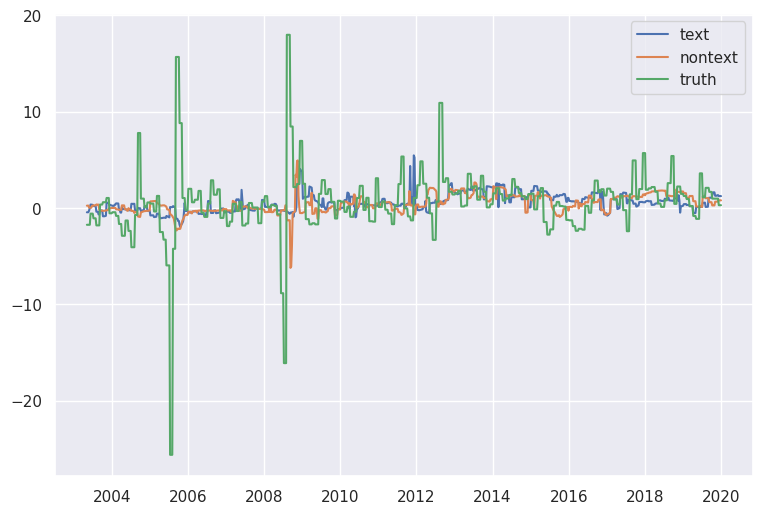

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
d_var = 'DProd'

fig, ax = plt.subplots(figsize=(9,6))
df = pd.read_csv(f"res_Forward_Lasso/0-1_{d_var}.csv", index_col=0)
df.index = pd.to_datetime(df.index)
ax.plot(df['pred'], label='text')
df = pd.read_csv(f"res_Forward_Lasso/1-0_{d_var}.csv", index_col=0)
df.index = pd.to_datetime(df.index)
ax.plot(df['pred'], label='nontext')
ax.plot(df['true'], label='truth')
ax.legend();

text: 1, 2, 3, 3, 3, 1 |
nont: 2, 1, 2, 1, 3, 2 |
both: 1, 2, 3, 3, 3, 3 | 

vote: 1, 2, 3, 3, 3, 1 | 2, 3, 1

only make forecasts when the model is in there optimal tercile
if no model is in its optimal tercile, we do not make forecast
ensemble is the average of three blanked series in both selection and evaluation
three columns of predictions only in their optimal: np.nanmean() in rows